データ拡張する，CNNと自分の手法どっちも

In [1]:
import os
import shutil
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import Subset
from sklearn.model_selection import StratifiedKFold
from PIL import Image

def generate_datasets():
    # -----------------------------
    # 設定
    # -----------------------------
    SOURCE_DATA_DIR = '/home/data/1021_fasttest/crop' # 元データ
    OUTPUT_ROOT = '/home/data/0107_generated_datasets_aug' # 保存先(変更してください)
    
    NUM_CLASSES = 3
    K_FOLDS = 6
    TARGET_TOTAL_SIZES = [18, 30, 42, 54, 66, 72, 84, 96, 108, 120, 132, 144, 156]
    
    # データ拡張の設定（保存時に適用）
    # ここでは例として「左右反転」と「回転」を行います
    augment_functions = [
        # パターン1: 水平反転
        (lambda img: img.transpose(Image.FLIP_LEFT_RIGHT), "_flip"),
        # パターン2: 回転 (+30度)
        (lambda img: img.rotate(30), "_rot30"),
        # パターン3: 回転 (-30度)
        (lambda img: img.rotate(-30), "_rot_30"),
    ]
    
    # -----------------------------
    # 準備
    # -----------------------------
    # 画像読み込み用に標準的な変換のみ定義（Resize等は学習時にやるので、ここではPILのまま扱うため変換しない）
    full_dataset = datasets.ImageFolder(SOURCE_DATA_DIR)
    class_names = full_dataset.classes
    all_targets = np.array(full_dataset.targets)
    
    print(f"クラス: {class_names}")
    print(f"保存先: {OUTPUT_ROOT}")

    # -----------------------------
    # ループ処理
    # -----------------------------
    for total_size_req in TARGET_TOTAL_SIZES:
        IMAGES_PER_CLASS = total_size_req // NUM_CLASSES
        ACTUAL_TOTAL = IMAGES_PER_CLASS * NUM_CLASSES
        SEED_VALUE = total_size_req
        
        print(f"\n★ データセット作成: 目標 {total_size_req}枚 (実数 {ACTUAL_TOTAL})")
        
        # 1. データ抽出 (学習コードと同一ロジック)
        used_indices = []
        used_labels = []
        np.random.seed(SEED_VALUE)
        
        for class_idx in range(NUM_CLASSES):
            indices_of_class = np.where(all_targets == class_idx)[0]
            if len(indices_of_class) < IMAGES_PER_CLASS:
                select_num = len(indices_of_class)
            else:
                select_num = IMAGES_PER_CLASS
            
            np.random.shuffle(indices_of_class)
            selected_indices = indices_of_class[:select_num]
            used_indices.extend(selected_indices)
            used_labels.extend([class_idx] * len(selected_indices))
            
        used_indices = np.array(used_indices)
        used_labels = np.array(used_labels)

        # 2. K-Fold 分割と保存
        skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
        
        for fold, (train_idx_in_subset, val_idx_in_subset) in enumerate(skf.split(used_indices, used_labels)):
            fold_name = f"Fold_{fold+1}"
            size_name = f"Total_{ACTUAL_TOTAL}"
            
            # 保存パス: root/Total_XX/Fold_Y/train/class_name/
            base_dir = os.path.join(OUTPUT_ROOT, size_name, fold_name)
            train_dir = os.path.join(base_dir, 'train')
            val_dir = os.path.join(base_dir, 'val')
            
            # ディレクトリ作成 (既にある場合は一度消すか、上書き注意)
            if os.path.exists(base_dir):
                shutil.rmtree(base_dir)
            
            # --- 保存処理関数 ---
            def save_images(indices, root_dir, is_train):
                for idx in indices:
                    # 元画像のパスとラベルを取得
                    original_path, label = full_dataset.samples[idx]
                    class_name = class_names[label]
                    
                    # 出力先フォルダ
                    target_class_dir = os.path.join(root_dir, class_name)
                    os.makedirs(target_class_dir, exist_ok=True)
                    
                    # 画像を開く
                    img = Image.open(original_path).convert('RGB')
                    filename = os.path.basename(original_path)
                    name_base, ext = os.path.splitext(filename)
                    
                    # 1. オリジナルを保存
                    save_path = os.path.join(target_class_dir, filename)
                    img.save(save_path)
                    
                    # 2. 訓練データならデータ拡張して保存
                    if is_train:
                        for func, suffix in augment_functions:
                            aug_img = func(img)
                            aug_name = f"{name_base}{suffix}{ext}"
                            aug_path = os.path.join(target_class_dir, aug_name)
                            aug_img.save(aug_path)

            # 実際の保存実行
            real_train_indices = used_indices[train_idx_in_subset]
            real_val_indices = used_indices[val_idx_in_subset]
            
            save_images(real_train_indices, train_dir, is_train=True)
            save_images(real_val_indices, val_dir, is_train=False) # 検証用は拡張しない
            
            print(f"  -> {size_name} / {fold_name} 保存完了 (Train: {len(real_train_indices)}x{1+len(augment_functions)}枚, Val: {len(real_val_indices)}枚)")

if __name__ == '__main__':
    generate_datasets()

クラス: ['A', 'B', 'C']
保存先: /home/data/0107_generated_datasets_aug

★ データセット作成: 目標 18枚 (実数 18)
  -> Total_18 / Fold_1 保存完了 (Train: 15x4枚, Val: 3枚)
  -> Total_18 / Fold_2 保存完了 (Train: 15x4枚, Val: 3枚)
  -> Total_18 / Fold_3 保存完了 (Train: 15x4枚, Val: 3枚)
  -> Total_18 / Fold_4 保存完了 (Train: 15x4枚, Val: 3枚)
  -> Total_18 / Fold_5 保存完了 (Train: 15x4枚, Val: 3枚)
  -> Total_18 / Fold_6 保存完了 (Train: 15x4枚, Val: 3枚)

★ データセット作成: 目標 30枚 (実数 30)
  -> Total_30 / Fold_1 保存完了 (Train: 25x4枚, Val: 5枚)
  -> Total_30 / Fold_2 保存完了 (Train: 25x4枚, Val: 5枚)
  -> Total_30 / Fold_3 保存完了 (Train: 25x4枚, Val: 5枚)
  -> Total_30 / Fold_4 保存完了 (Train: 25x4枚, Val: 5枚)
  -> Total_30 / Fold_5 保存完了 (Train: 25x4枚, Val: 5枚)
  -> Total_30 / Fold_6 保存完了 (Train: 25x4枚, Val: 5枚)

★ データセット作成: 目標 42枚 (実数 42)
  -> Total_42 / Fold_1 保存完了 (Train: 35x4枚, Val: 7枚)
  -> Total_42 / Fold_2 保存完了 (Train: 35x4枚, Val: 7枚)
  -> Total_42 / Fold_3 保存完了 (Train: 35x4枚, Val: 7枚)
  -> Total_42 / Fold_4 保存完了 (Train: 35x4枚, Val: 7枚)
  -> Total_42 / Fol

In [1]:
import os
import shutil
import numpy as np
import torch
from torchvision import datasets
from sklearn.model_selection import StratifiedKFold
from PIL import Image

def generate_multi_datasets_suffix_aware():
    # -----------------------------
    # 1. 設定
    # -----------------------------
    # 基準となるディレクトリ（ここからファイルリストを取得します）
    BASE_SOURCE_DIR = '/home/data/1021_fasttest/crop'
    
    # ★変更点: パスと「ファイル名の識別子(サフィックス)」をセットで定義
    DATA_SOURCES = {
        'crop':     {'path': '/home/data/1021_fasttest/crop',     'suffix': '_crop'},
        'mask':     {'path': '/home/data/1021_fasttest/mask',     'suffix': '_mask'},
        'combined': {'path': '/home/data/1021_fasttest/combined', 'suffix': '_combined'}
    }

    OUTPUT_ROOT = '/home/data/0107_generated_datasets_multi' # 保存先ルート
    
    NUM_CLASSES = 3
    K_FOLDS = 6
    TARGET_TOTAL_SIZES = [18, 30, 42, 54, 66, 72, 84, 96, 108, 120, 132, 144, 156]
    
    # データ拡張の設定（Trainデータのみに適用）
    augment_functions = [
        (lambda img: img.transpose(Image.FLIP_LEFT_RIGHT), "_flip"),
        (lambda img: img.rotate(30), "_rot30"),
        (lambda img: img.rotate(-30), "_rot_30"),
    ]
    
    # -----------------------------
    # 2. 準備（マスター情報の取得）
    # -----------------------------
    # cropフォルダを基準にクラスやファイル一覧を取得
    master_dataset = datasets.ImageFolder(BASE_SOURCE_DIR)
    class_names = master_dataset.classes
    all_targets = np.array(master_dataset.targets)
    
    print(f"検知クラス: {class_names}")
    print(f"保存先ルート: {OUTPUT_ROOT}")

    # -----------------------------
    # 3. メインループ処理
    # -----------------------------
    for total_size_req in TARGET_TOTAL_SIZES:
        IMAGES_PER_CLASS = total_size_req // NUM_CLASSES
        ACTUAL_TOTAL = IMAGES_PER_CLASS * NUM_CLASSES
        SEED_VALUE = total_size_req
        
        print(f"\n★ データセット作成: 目標 {total_size_req}枚 (実数 {ACTUAL_TOTAL})")
        
        # --- A. データ抽出 (インデックス決定) ---
        used_indices = []
        used_labels = []
        np.random.seed(SEED_VALUE)
        
        for class_idx in range(NUM_CLASSES):
            indices_of_class = np.where(all_targets == class_idx)[0]
            if len(indices_of_class) < IMAGES_PER_CLASS:
                select_num = len(indices_of_class)
            else:
                select_num = IMAGES_PER_CLASS
            
            np.random.shuffle(indices_of_class)
            selected_indices = indices_of_class[:select_num]
            used_indices.extend(selected_indices)
            used_labels.extend([class_idx] * len(selected_indices))
            
        used_indices = np.array(used_indices)
        used_labels = np.array(used_labels)

        # --- B. K-Fold 分割と保存 ---
        skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
        
        for fold, (train_idx_in_subset, val_idx_in_subset) in enumerate(skf.split(used_indices, used_labels)):
            fold_name = f"Fold_{fold+1}"
            size_name = f"Total_{ACTUAL_TOTAL}"

            real_train_indices = used_indices[train_idx_in_subset]
            real_val_indices = used_indices[val_idx_in_subset]
            
            # --- C. 保存実行関数 ---
            def process_and_save(indices, phase_name, is_train):
                for idx in indices:
                    # 1. マスター(crop)の情報を取得
                    # 例: master_path = .../crop/C/IMG_66016_crop.png
                    master_path, label = master_dataset.samples[idx]
                    class_name = class_names[label]
                    
                    # ディレクトリ部分 ("C") と ファイル名 ("IMG_66016_crop.png") を分離
                    rel_dir = os.path.dirname(os.path.relpath(master_path, start=BASE_SOURCE_DIR))
                    master_filename = os.path.basename(master_path)
                    
                    # 2. 各データソース (crop, mask, combined) ごとにループ
                    for type_name, info in DATA_SOURCES.items():
                        source_root = info['path']
                        target_suffix = info['suffix']
                        
                        # ★ここが重要: ファイル名の置換処理
                        # "_crop" を "_mask" や "_combined" に書き換える
                        if '_crop' in master_filename:
                            current_filename = master_filename.replace('_crop', target_suffix)
                        else:
                            # 万が一 _crop が含まれていない場合のフォールバック（そのまま使う）
                            current_filename = master_filename

                        # 読み込み元パスの構築
                        source_file_path = os.path.join(source_root, rel_dir, current_filename)
                        
                        # 保存先パスの構築
                        # 例: OUTPUT/combined/Total_18/Fold_1/train/C/
                        save_dir = os.path.join(OUTPUT_ROOT, type_name, size_name, fold_name, phase_name, class_name)
                        os.makedirs(save_dir, exist_ok=True)
                        
                        # ファイル存在確認
                        if not os.path.exists(source_file_path):
                            print(f"スキップ(見つかりません): {source_file_path}")
                            continue

                        # 画像を開く
                        try:
                            img = Image.open(source_file_path).convert('RGB')
                        except Exception as e:
                            print(f"読込エラー: {source_file_path} -> {e}")
                            continue

                        name_base, ext = os.path.splitext(current_filename)

                        # (1) オリジナル保存
                        img.save(os.path.join(save_dir, current_filename))
                        
                        # (2) データ拡張 (Trainのみ)
                        if is_train:
                            for func, suffix in augment_functions:
                                aug_img = func(img)
                                # 拡張ファイルの命名: IMG_66016_combined_rot30.png
                                aug_filename = f"{name_base}{suffix}{ext}"
                                aug_img.save(os.path.join(save_dir, aug_filename))

            # Train保存
            process_and_save(real_train_indices, 'train', is_train=True)
            # Val保存
            process_and_save(real_val_indices, 'val', is_train=False)
            
            print(f"  -> {size_name} / {fold_name} 完了")

if __name__ == '__main__':
    generate_multi_datasets_suffix_aware()

検知クラス: ['A', 'B', 'C']
保存先ルート: /home/data/0107_generated_datasets_multi

★ データセット作成: 目標 18枚 (実数 18)
  -> Total_18 / Fold_1 完了
  -> Total_18 / Fold_2 完了
  -> Total_18 / Fold_3 完了
  -> Total_18 / Fold_4 完了
  -> Total_18 / Fold_5 完了
  -> Total_18 / Fold_6 完了

★ データセット作成: 目標 30枚 (実数 30)
  -> Total_30 / Fold_1 完了
  -> Total_30 / Fold_2 完了
  -> Total_30 / Fold_3 完了
  -> Total_30 / Fold_4 完了
  -> Total_30 / Fold_5 完了
  -> Total_30 / Fold_6 完了

★ データセット作成: 目標 42枚 (実数 42)
  -> Total_42 / Fold_1 完了
  -> Total_42 / Fold_2 完了
  -> Total_42 / Fold_3 完了
  -> Total_42 / Fold_4 完了
  -> Total_42 / Fold_5 完了
  -> Total_42 / Fold_6 完了

★ データセット作成: 目標 54枚 (実数 54)
  -> Total_54 / Fold_1 完了
  -> Total_54 / Fold_2 完了
  -> Total_54 / Fold_3 完了
  -> Total_54 / Fold_4 完了
  -> Total_54 / Fold_5 完了
  -> Total_54 / Fold_6 完了

★ データセット作成: 目標 66枚 (実数 66)
  -> Total_66 / Fold_1 完了
  -> Total_66 / Fold_2 完了
  -> Total_66 / Fold_3 完了
  -> Total_66 / Fold_4 完了
  -> Total_66 / Fold_5 完了
  -> Total_66 / Fold_6 完了

★ データセッ

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import os
import matplotlib.pyplot as plt

def main():
    # -----------------------------
    # 1. 設定
    # -----------------------------
    # ★ 手順1で作成したフォルダを指定
    GENERATED_DATA_ROOT = '/home/data/0107_generated_datasets_aug'
    
    BATCH_SIZE = 8
    NUM_EPOCHS = 30
    LEARNING_RATE = 0.001
    NUM_CLASSES = 3
    K_FOLDS = 6
    
    # 生成したディレクトリ名に合わせて指定
    TARGET_TOTAL_SIZES = [18, 30, 42, 54, 66, 72, 84, 96, 108, 120, 132, 144, 156] 

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"使用デバイス: {device}")

    # 前処理 (Resize等はここで行う)
    data_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # =========================================================
    # ループ開始
    # =========================================================
    for total_size_req in TARGET_TOTAL_SIZES:
        # パラメータ再計算（ディレクトリ名特定のため）
        IMAGES_PER_CLASS = total_size_req // NUM_CLASSES
        ACTUAL_TOTAL = IMAGES_PER_CLASS * NUM_CLASSES
        
        # 結果保存先
        SAVE_DIR = f'resnet18_aug_cv_total{ACTUAL_TOTAL}' # フォルダ名を変えて区別
        os.makedirs(SAVE_DIR, exist_ok=True)
        
        print(f"\n========================================================")
        print(f"★ 学習開始: データセット Total_{ACTUAL_TOTAL}")
        print(f"========================================================")

        # Foldごとのループ
        for fold in range(1, K_FOLDS + 1):
            fold_name = f"Fold_{fold}"
            print(f"\n--- {fold_name} ---")
            
            # 保存されたデータセットへのパス
            train_dir = os.path.join(GENERATED_DATA_ROOT, f"Total_{ACTUAL_TOTAL}", fold_name, 'train')
            val_dir = os.path.join(GENERATED_DATA_ROOT, f"Total_{ACTUAL_TOTAL}", fold_name, 'val')
            
            if not os.path.exists(train_dir):
                print(f"エラー: データフォルダが見つかりません {train_dir}")
                continue

            # データ読み込み
            train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms)
            val_dataset = datasets.ImageFolder(val_dir, transform=data_transforms)
            
            train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
            val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
            
            print(f"  Train枚数: {len(train_dataset)} (拡張済), Val枚数: {len(val_dataset)}")

            # --- 以下、モデル構築・学習・保存処理は元のコードと同じ ---
            model = models.resnet18(weights=None)
            model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
            model = model.to(device)

            criterion = nn.CrossEntropyLoss()
            optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

            history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

            for epoch in range(NUM_EPOCHS):
                model.train()
                running_loss, correct, total = 0.0, 0, 0

                for inputs, labels in train_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    optimizer.zero_grad()
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    _, predicted = torch.max(outputs, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

                epoch_loss = running_loss / len(train_dataset)
                epoch_acc = correct / total

                model.eval()
                val_loss, val_correct, val_total = 0.0, 0, 0
                with torch.no_grad():
                    for inputs, labels in val_loader:
                        inputs, labels = inputs.to(device), labels.to(device)
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)
                        val_loss += loss.item() * inputs.size(0)
                        _, predicted = torch.max(outputs, 1)
                        val_total += labels.size(0)
                        val_correct += (predicted == labels).sum().item()

                val_epoch_loss = val_loss / len(val_dataset)
                val_epoch_acc = val_correct / val_total

                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc)
                history['val_loss'].append(val_epoch_loss)
                history['val_acc'].append(val_epoch_acc)

            # 保存
            torch.save(model.state_dict(), os.path.join(SAVE_DIR, f'resnet18_fold{fold}.pth'))

            # グラフ作成
            plt.figure(figsize=(10, 4))
            plt.subplot(1, 2, 1)
            plt.plot(history['train_loss'], label='Train')
            plt.plot(history['val_loss'], label='Val')
            plt.title(f'Loss (Total {ACTUAL_TOTAL})')
            plt.legend()
            plt.grid()

            plt.subplot(1, 2, 2)
            plt.plot(history['train_acc'], label='Train')
            plt.plot(history['val_acc'], label='Val')
            plt.title(f'Acc (Total {ACTUAL_TOTAL})')
            plt.legend()
            plt.grid()

            plt.savefig(os.path.join(SAVE_DIR, f'curve_fold{fold}.png'))
            plt.close()

if __name__ == '__main__':
    main()

使用デバイス: cpu

★ 学習開始: データセット Total_18

--- Fold_1 ---
  Train枚数: 60 (拡張済), Val枚数: 3

--- Fold_2 ---
  Train枚数: 60 (拡張済), Val枚数: 3

--- Fold_3 ---
  Train枚数: 60 (拡張済), Val枚数: 3

--- Fold_4 ---
  Train枚数: 60 (拡張済), Val枚数: 3

--- Fold_5 ---
  Train枚数: 60 (拡張済), Val枚数: 3

--- Fold_6 ---
  Train枚数: 60 (拡張済), Val枚数: 3

★ 学習開始: データセット Total_30

--- Fold_1 ---
  Train枚数: 100 (拡張済), Val枚数: 5

--- Fold_2 ---
  Train枚数: 100 (拡張済), Val枚数: 5

--- Fold_3 ---
  Train枚数: 100 (拡張済), Val枚数: 5

--- Fold_4 ---
  Train枚数: 100 (拡張済), Val枚数: 5

--- Fold_5 ---
  Train枚数: 100 (拡張済), Val枚数: 5

--- Fold_6 ---
  Train枚数: 100 (拡張済), Val枚数: 5

★ 学習開始: データセット Total_42

--- Fold_1 ---
  Train枚数: 140 (拡張済), Val枚数: 7

--- Fold_2 ---
  Train枚数: 140 (拡張済), Val枚数: 7

--- Fold_3 ---
  Train枚数: 140 (拡張済), Val枚数: 7

--- Fold_4 ---
  Train枚数: 140 (拡張済), Val枚数: 7

--- Fold_5 ---
  Train枚数: 140 (拡張済), Val枚数: 7

--- Fold_6 ---
  Train枚数: 140 (拡張済), Val枚数: 7

★ 学習開始: データセット Total_54

--- Fold_1 ---
  Train枚数: 180 (拡張済), Val枚数: 9



KeyboardInterrupt: 

使用デバイス: cpu

★ 評価開始: データセット Total_18
   重みフォルダ: resnet18_aug_cv_total18
 -> 平均正解率: 0.7222

★ 評価開始: データセット Total_30
   重みフォルダ: resnet18_aug_cv_total30
 -> 平均正解率: 0.5000

★ 評価開始: データセット Total_42
   重みフォルダ: resnet18_aug_cv_total42
 -> 平均正解率: 0.6667

★ 評価開始: データセット Total_54
   重みフォルダ: resnet18_aug_cv_total54
 -> 平均正解率: 0.5741

★ 評価開始: データセット Total_66
   重みフォルダ: resnet18_aug_cv_total66
 -> 平均正解率: 0.6364

★ 全評価完了。'final_evaluation_summary.csv' を保存しました。
★ 推移グラフ 'accuracy_transition_graph.png' を保存しました。


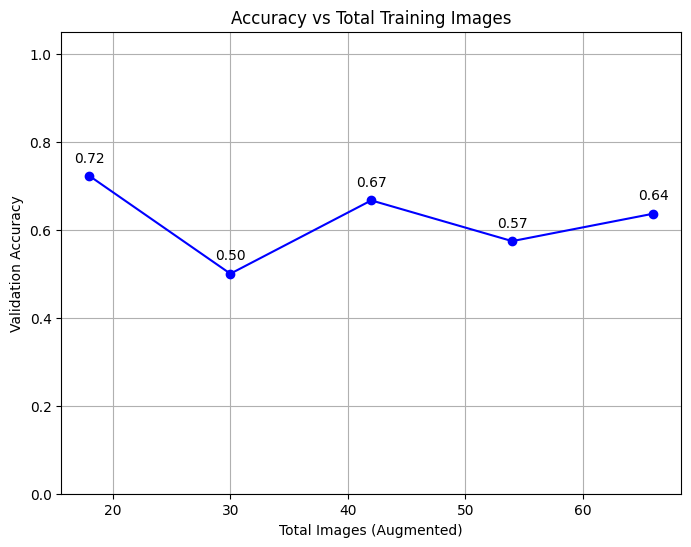

In [6]:
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

def main():
    # -----------------------------
    # 1. 設定 (学習時と合わせる)
    # -----------------------------
    # 検証データ(val)が入っているルート
    GENERATED_DATA_ROOT = '/home/data/0107_generated_datasets_aug'
    
    BATCH_SIZE = 8
    NUM_CLASSES = 3
    K_FOLDS = 6
    
    # 評価したいデータサイズリスト
    # TARGET_TOTAL_SIZES = [18, 30, 42, 54, 66, 72, 84, 96, 108, 120, 132, 144, 156] 
    TARGET_TOTAL_SIZES = [18, 30, 42, 54, 66,] 


    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"使用デバイス: {device}")

    # 前処理 (評価用なので正規化のみ。拡張はしない)
    data_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # 全実験の結果まとめ用リスト
    global_results = []

    # =========================================================
    # ループ開始
    # =========================================================
    for total_size_req in TARGET_TOTAL_SIZES:
        # 学習時と同じ計算でフォルダ名を特定
        IMAGES_PER_CLASS = total_size_req // NUM_CLASSES
        ACTUAL_TOTAL = IMAGES_PER_CLASS * NUM_CLASSES
        
        # モデルの重みがあるフォルダ
        WEIGHT_DIR = f'resnet18_aug_cv_total{ACTUAL_TOTAL}'
        
        print(f"\n========================================================")
        print(f"★ 評価開始: データセット Total_{ACTUAL_TOTAL}")
        print(f"   重みフォルダ: {WEIGHT_DIR}")
        print(f"========================================================")
        
        if not os.path.exists(WEIGHT_DIR):
            print(f"スキップ: 重みフォルダが見つかりません {WEIGHT_DIR}")
            continue

        fold_accuracies = []

        # Foldごとのループ
        for fold in range(1, K_FOLDS + 1):
            fold_name = f"Fold_{fold}"
            # print(f" - {fold_name} 評価中...")

            # 1. データセット読み込み
            val_dir = os.path.join(GENERATED_DATA_ROOT, f"Total_{ACTUAL_TOTAL}", fold_name, 'val')
            if not os.path.exists(val_dir):
                print(f"  エラー: データなし {val_dir}")
                continue

            val_dataset = datasets.ImageFolder(val_dir, transform=data_transforms)
            val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
            class_names = val_dataset.classes

            # 2. モデル準備 & 重みロード
            model = models.resnet18(weights=None)
            model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
            
            weight_path = os.path.join(WEIGHT_DIR, f'resnet18_fold{fold}.pth')
            if not os.path.exists(weight_path):
                print(f"  警告: 重みファイルなし {weight_path}")
                continue
                
            model.load_state_dict(torch.load(weight_path, map_location=device))
            model = model.to(device)
            model.eval()

            # 3. 推論実行
            all_preds = []
            all_labels = []
            
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs = inputs.to(device)
                    outputs = model(inputs)
                    _, predicted = torch.max(outputs, 1)
                    
                    all_preds.extend(predicted.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())

            # 4. 指標計算
            acc = accuracy_score(all_labels, all_preds)
            fold_accuracies.append(acc)
            
            # 混同行列の作成と保存
            cm = confusion_matrix(all_labels, all_preds)
            
            # 
            plt.figure(figsize=(6, 5))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
            plt.title(f'Total {ACTUAL_TOTAL} - {fold_name}\nAcc: {acc:.2%}')
            plt.ylabel('True Label')
            plt.xlabel('Predicted Label')
            plt.tight_layout()
            plt.savefig(os.path.join(WEIGHT_DIR, f'confusion_matrix_fold{fold}.png'))
            plt.close()

        # Fold平均の計算
        if fold_accuracies:
            avg_acc = np.mean(fold_accuracies)
            print(f" -> 平均正解率: {avg_acc:.4f}")
            
            global_results.append({
                'Total_Images': ACTUAL_TOTAL,
                'Average_Accuracy': avg_acc,
                'Fold_Scores': fold_accuracies
            })

    # =========================================================
    # 最終まとめ出力
    # =========================================================
    if global_results:
        # CSV保存
        df = pd.DataFrame(global_results)
        df.to_csv('final_evaluation_summary.csv', index=False)
        print("\n★ 全評価完了。'final_evaluation_summary.csv' を保存しました。")
        
        # グラフ作成 (データ数 vs 精度)
        # 
        plt.figure(figsize=(8, 6))
        plt.plot(df['Total_Images'], df['Average_Accuracy'], marker='o', linestyle='-', color='b')
        plt.title('Accuracy vs Total Training Images')
        plt.xlabel('Total Images (Augmented)')
        plt.ylabel('Validation Accuracy')
        plt.grid(True)
        plt.ylim(0, 1.05) # 0%〜100%表示
        
        for i, txt in enumerate(df['Average_Accuracy']):
            plt.annotate(f"{txt:.2f}", (df['Total_Images'][i], df['Average_Accuracy'][i]), textcoords="offset points", xytext=(0,10), ha='center')
            
        plt.savefig('accuracy_transition_graph.png')
        print("★ 推移グラフ 'accuracy_transition_graph.png' を保存しました。")
        
    else:
        print("評価結果がありませんでした。パスなどを確認してください。")

if __name__ == '__main__':
    main()

In [4]:
# crop,mask,combinedの各フォルダ内のサブフォルダを消して直下に全画像を移動するスクリプト

import os
import shutil
from tqdm import tqdm # 進捗表示用 (なければ pip install tqdm または printで代用)

def flatten_directories():
    # -----------------------------
    # 1. 設定
    # -----------------------------
    # 現在、拡張済みのデータが入っているルートディレクトリ
    # 例: 前回作成した '/home/data/0107_generated_datasets_multi'
    INPUT_ROOT = '/home/data/0107_generated_datasets_multi'

    # フラットにしたファイルを保存する新しいルートディレクトリ
    # ※ 安全のため、元のフォルダを書き換えず、新しい場所にコピーすることをお勧めします
    OUTPUT_ROOT = '/home/data/0107_tomine'
    
    TARGET_TYPES = ['crop', 'mask', 'combined']
    
# -----------------------------
    # 2. 実行
    # -----------------------------
    for type_name in TARGET_TYPES:
        src_root = os.path.join(INPUT_ROOT, type_name)
        dst_type_root = os.path.join(OUTPUT_ROOT, type_name)
        
        print(f"\nProcessing: {type_name}")
        print(f" Source: {src_root}")
        print(f" Dest  : {dst_type_root}")
        
        if not os.path.exists(src_root):
            print(f"  Warning: ソースフォルダ {src_root} が見つかりません。スキップします。")
            continue

        # 新規作成時はフォルダをクリア（安全のためコメントアウトしていますが、必要なら有効化）
        if os.path.exists(dst_type_root):
            shutil.rmtree(dst_type_root)
        
        count = 0
        
        # os.walkでサブフォルダを全探索
        # rootには現在見ているディレクトリパスが入ります（例: .../Total_18/Fold_1/train/A）
        for root, dirs, files in os.walk(src_root):
            for filename in files:
                # 画像ファイルのみ対象
                if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                    
                    # --- クラス名の特定 ---
                    # 元の構造が「.../クラス名/画像ファイル」となっていることを利用します
                    # rootの末尾（フォルダ名）がクラス名（A, B, C等）になります
                    class_name = os.path.basename(root)
                    
                    # 万が一、クラス名ではなく "train" や "val" フォルダ直下に画像がある場合の対策
                    # （通常のImageFolder構造なら A/B/C の中にあるはずなので、ここはそのままクラス名として扱います）
                    
                    # --- 保存先の構築 ---
                    # 例: /home/data/0107_organized/combined/A/
                    target_dir = os.path.join(dst_type_root, class_name)
                    os.makedirs(target_dir, exist_ok=True)
                    
                    # --- ファイルコピー ---
                    src_path = os.path.join(root, filename)
                    dst_path = os.path.join(target_dir, filename)
                    
                    # 上書きコピー (shutil.copy2 はメタデータもコピーします)
                    # 異なるFoldやTotalサイズに含まれる同一画像は上書きされます（中身は同じなので問題ありません）
                    shutil.copy2(src_path, dst_path)
                    count += 1
        
        print(f"  -> {count} ファイルを整理して {dst_type_root} に保存しました。")

    print("\n完了しました。")
    print(f"保存先: {OUTPUT_ROOT}")

if __name__ == '__main__':
    flatten_directories()


Processing: crop
 Source: /home/data/0107_generated_datasets_multi/crop
 Dest  : /home/data/0107_tomine/crop
  -> 23562 ファイルを整理して /home/data/0107_tomine/crop に保存しました。

Processing: mask
 Source: /home/data/0107_generated_datasets_multi/mask
 Dest  : /home/data/0107_tomine/mask
  -> 23562 ファイルを整理して /home/data/0107_tomine/mask に保存しました。

Processing: combined
 Source: /home/data/0107_generated_datasets_multi/combined
 Dest  : /home/data/0107_tomine/combined
  -> 23562 ファイルを整理して /home/data/0107_tomine/combined に保存しました。

完了しました。
保存先: /home/data/0107_tomine


Loading feature data from: /home/data/0107_tomine/feature_huall.csv
有効な特徴量データ数: 2684

Processing: Total_18
 -> Average Accuracy: 0.5556

Processing: Total_30
 -> Average Accuracy: 0.4000

Processing: Total_42
 -> Average Accuracy: 0.4524

Processing: Total_54
 -> Average Accuracy: 0.5000

Processing: Total_66
 -> Average Accuracy: 0.3485

Saved Summary CSV: /home/src/deeplerning_model/CNNvsmine/svm_comparison/svm_results_matched.csv
Saved Detailed CSV: /home/src/deeplerning_model/CNNvsmine/svm_comparison/svm_classification_details.csv
Saved Error Cases CSV: /home/src/deeplerning_model/CNNvsmine/svm_comparison/svm_error_cases.csv
Saved Graph: /home/src/deeplerning_model/CNNvsmine/svm_comparison/svm_accuracy_transition.png


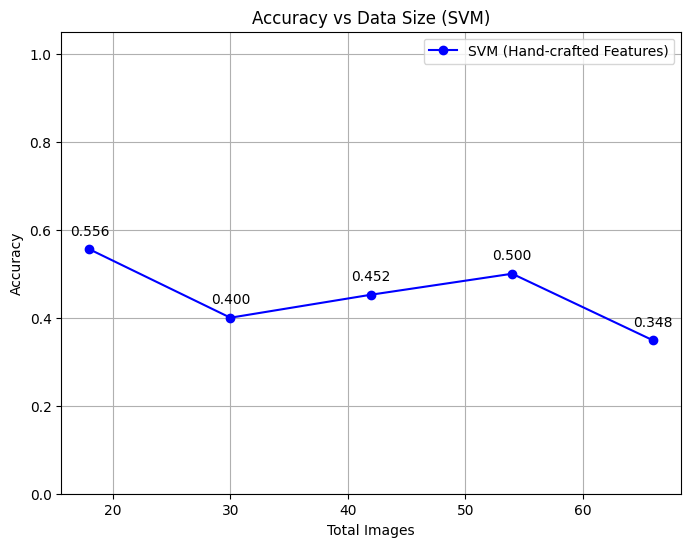

In [14]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import glob

def main():
    # ==========================================
    # 1. 設定パラメータ
    # ==========================================
    FEATURE_CSV_PATH = "/home/data/0107_tomine/feature_huall.csv"
    DATASET_ROOT = "/home/data/0107_generated_datasets_aug"
    OUTPUT_DIR = "/home/src/deeplerning_model/CNNvsmine/svm_comparison"
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    FEATURE_COLS = ['size_count', 'R', 'h0', 'h2', 'h3', 'h7']
    TARGET_TOTAL_SIZES = [18, 30, 42, 54, 66]
    
    CLASS_NAMES = ['A', 'B', 'C']
    LABEL_MAP = {name: i for i, name in enumerate(CLASS_NAMES)}
    ID_TO_LABEL = {i: name for name, i in LABEL_MAP.items()}

    print(f"Loading feature data from: {FEATURE_CSV_PATH}")
    if not os.path.exists(FEATURE_CSV_PATH):
        print("エラー: 特徴量CSVが見つかりません。")
        return

    # -------------------------------------------------------
    # 2. 特徴量データベースの構築
    # -------------------------------------------------------
    df_raw = pd.read_csv(FEATURE_CSV_PATH)
    for col in FEATURE_COLS:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
    df_raw = df_raw.dropna(subset=FEATURE_COLS)

    def get_clean_key_from_csv(filename):
        name = str(filename)
        name = os.path.splitext(name)[0]
        for suffix in ['_mask', '_crop', '_combined']:
            name = name.replace(suffix, '')
        return name

    df_raw['match_key'] = df_raw['filename'].apply(get_clean_key_from_csv)
    df_features = df_raw.drop_duplicates(subset=['match_key']).set_index('match_key')
    
    print(f"有効な特徴量データ数: {len(df_features)}")

    # -------------------------------------------------------
    # 3. データサイズごとのループ
    # -------------------------------------------------------
    global_results = []
    detailed_results = [] 

    for total_size in TARGET_TOTAL_SIZES:
        NUM_CLASSES = 3
        IMAGES_PER_CLASS = total_size // NUM_CLASSES
        ACTUAL_TOTAL = IMAGES_PER_CLASS * NUM_CLASSES
        
        target_dir_name = f"Total_{ACTUAL_TOTAL}"
        size_root = os.path.join(DATASET_ROOT, target_dir_name)
        
        print(f"\n========================================")
        print(f"Processing: {target_dir_name}")
        
        if not os.path.exists(size_root):
            print(f" スキップ: フォルダなし {size_root}")
            continue

        fold_accuracies = []
        fold_f1s = []

        # Foldループ
        for fold in range(1, 7):
            fold_name = f"Fold_{fold}"
            fold_dir = os.path.join(size_root, fold_name)
            
            if not os.path.exists(fold_dir):
                continue
            
            def load_features_from_images(phase):
                phase_dir = os.path.join(fold_dir, phase)
                X_list = []
                y_list = []
                keys_list = [] 
                
                for class_name in CLASS_NAMES:
                    class_dir = os.path.join(phase_dir, class_name)
                    if not os.path.exists(class_dir):
                        continue
                        
                    files = os.listdir(class_dir)
                    for f in files:
                        if not f.lower().endswith(('.png', '.jpg')):
                            continue
                        
                        base_name = os.path.splitext(f)[0]
                        key = base_name
                        for aug_suffix in ['_flip', '_rot30', '_rot_30']:
                            key = key.replace(aug_suffix, '')
                        key = get_clean_key_from_csv(key) 
                        
                        if key in df_features.index:
                            feats = df_features.loc[key, FEATURE_COLS].values.astype(float)
                            X_list.append(feats)
                            y_list.append(LABEL_MAP[class_name])
                            keys_list.append(key)
                            
                return np.array(X_list), np.array(y_list), keys_list

            X_train, y_train, _ = load_features_from_images('train')
            X_val, y_val, val_keys = load_features_from_images('val')
            
            if len(X_train) == 0 or len(X_val) == 0:
                print(f"  {fold_name}: データ不足")
                continue

            # SVM学習
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('svm', SVC(class_weight='balanced', random_state=42))
            ])
            
            param_grid = {
                'svm__C': [0.1, 1, 10, 100],
                'svm__gamma': ['scale', 'auto'],
                'svm__kernel': ['rbf']
            }
            
            inner_cv = min(3, len(X_train) // 3)
            if inner_cv < 2: inner_cv = 2
            
            grid = GridSearchCV(pipeline, param_grid, cv=inner_cv, scoring='accuracy', n_jobs=-1)
            grid.fit(X_train, y_train)
            
            best_model = grid.best_estimator_
            preds = best_model.predict(X_val)
            
            acc = accuracy_score(y_val, preds)
            report = classification_report(y_val, preds, output_dict=True, zero_division=0)
            
            fold_accuracies.append(acc)
            fold_f1s.append(report['macro avg']['f1-score'])
            
            for i in range(len(y_val)):
                true_label_name = ID_TO_LABEL[y_val[i]]
                pred_label_name = ID_TO_LABEL[preds[i]]
                is_correct = (y_val[i] == preds[i])
                
                detailed_results.append({
                    'Total_Images': ACTUAL_TOTAL,
                    'Fold': fold,
                    'Image_ID': val_keys[i],
                    'True_Label': true_label_name,
                    'Predicted_Label': pred_label_name,
                    'Is_Correct': is_correct
                })

        if fold_accuracies:
            avg_acc = np.mean(fold_accuracies)
            avg_f1 = np.mean(fold_f1s)
            print(f" -> Average Accuracy: {avg_acc:.4f}")
            
            global_results.append({
                'Total_Images': ACTUAL_TOTAL,
                'Requested_Images': total_size,
                'SVM_Accuracy': avg_acc,
                'SVM_Macro_F1': avg_f1
            })

    # -------------------------------------------------------
    # 4. 結果保存
    # -------------------------------------------------------
    if global_results:
        results_df = pd.DataFrame(global_results)
        save_path = os.path.join(OUTPUT_DIR, "svm_results_matched.csv")
        results_df.to_csv(save_path, index=False)
        print(f"\nSaved Summary CSV: {save_path}")
        
        if detailed_results:
            detail_df = pd.DataFrame(detailed_results)
            detail_save_path = os.path.join(OUTPUT_DIR, "svm_classification_details.csv")
            detail_df.to_csv(detail_save_path, index=False)
            print(f"Saved Detailed CSV: {detail_save_path}")
            
            error_df = detail_df[detail_df['Is_Correct'] == False]
            error_save_path = os.path.join(OUTPUT_DIR, "svm_error_cases.csv")
            error_df.to_csv(error_save_path, index=False)
            print(f"Saved Error Cases CSV: {error_save_path}")

        # ---------------------------------------------------
        # ★ グラフ描画（数値ラベル付き）
        # ---------------------------------------------------
        plt.figure(figsize=(8, 6))
        plt.plot(results_df['Total_Images'], results_df['SVM_Accuracy'], marker='o', linestyle='-', color='b', label='SVM (Hand-crafted Features)')
        
        # 数値の書き込み処理
        for x, y in zip(results_df['Total_Images'], results_df['SVM_Accuracy']):
            label = f"{y:.3f}"  # 小数点3桁まで表示
            plt.annotate(label, 
                         (x, y), 
                         textcoords="offset points", 
                         xytext=(0, 10), # ポイントの10ピクセル上に表示
                         ha='center') 

        plt.title('Accuracy vs Data Size (SVM)')
        plt.xlabel('Total Images')
        plt.ylabel('Accuracy')
        plt.grid(True)
        plt.ylim(0, 1.05)
        plt.legend()
        
        

        graph_path = os.path.join(OUTPUT_DIR, "svm_accuracy_transition.png")
        plt.savefig(graph_path)
        print(f"Saved Graph: {graph_path}")
    else:
        print("有効な結果が得られませんでした。")

if __name__ == "__main__":
    main()

データを読み込んでいます...
結合完了: 5 行のデータを生成しました。
   Total_Images  ResNet_Accuracy  SVM_Accuracy
0            18         0.722222      0.555556
1            30         0.500000      0.400000
2            42         0.666667      0.452381
3            54         0.574074      0.500000
4            66         0.636364      0.348485

保存完了: /home/src/deeplerning_model/CNNvsmine/comparison_result/model_comparison_summary.csv
グラフ保存完了: /home/src/deeplerning_model/CNNvsmine/comparison_result/accuracy_comparison_graph.png


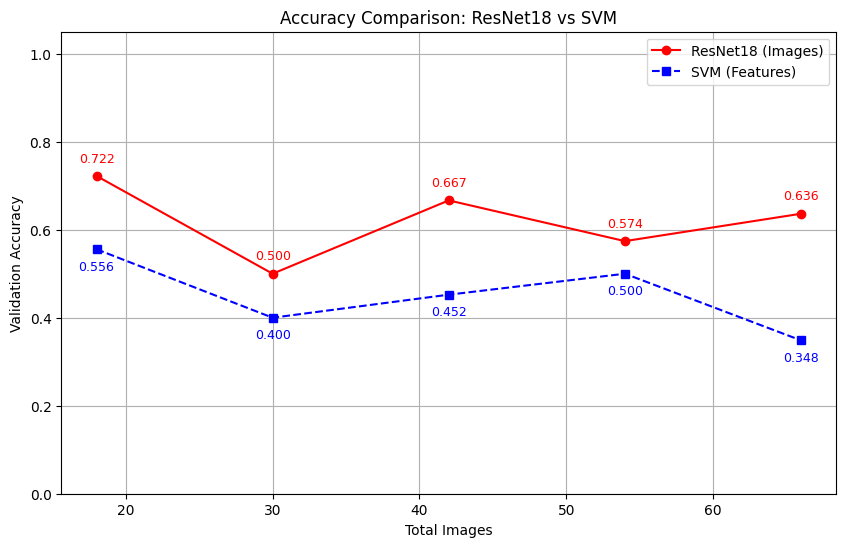

In [22]:
import pandas as pd
import os
import matplotlib.pyplot as plt

def main():
    # ==========================================
    # 1. 設定
    # ==========================================
    # 入力ファイルパス
    RESNET_CSV_PATH = "/home/src/deeplerning_model/CNNvsmine/final_evaluation_summary.csv"
    SVM_CSV_PATH = "/home/src/deeplerning_model/CNNvsmine/svm_comparison/svm_results_matched.csv"
    
    # 出力先ディレクトリ
    OUTPUT_DIR = "/home/src/deeplerning_model/CNNvsmine/comparison_result"
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # ==========================================
    # 2. データ読み込み
    # ==========================================
    print("データを読み込んでいます...")
    
    if not os.path.exists(RESNET_CSV_PATH) or not os.path.exists(SVM_CSV_PATH):
        print("エラー: 入力CSVファイルが見つかりません。パスを確認してください。")
        print(f"ResNet: {RESNET_CSV_PATH} ({os.path.exists(RESNET_CSV_PATH)})")
        print(f"SVM   : {SVM_CSV_PATH} ({os.path.exists(SVM_CSV_PATH)})")
        return

    df_resnet = pd.read_csv(RESNET_CSV_PATH)
    df_svm = pd.read_csv(SVM_CSV_PATH)

    # カラム名の確認と整理（結合前に名前が被らないようにする）
    # ResNet側の 'Average_Accuracy' を 'ResNet_Accuracy' に変更
    if 'Average_Accuracy' in df_resnet.columns:
        df_resnet = df_resnet.rename(columns={'Average_Accuracy': 'ResNet_Accuracy'})
    
    # 不要なカラムがあれば整理（必要に応じて調整してください）
    # ここでは Total_Images と Accuracy 関連を残します
    resnet_cols = ['Total_Images', 'ResNet_Accuracy']
    # もしMacro F1などもあれば追加
    if 'Average_Macro_F1' in df_resnet.columns:
        resnet_cols.append('Average_Macro_F1')
        df_resnet = df_resnet.rename(columns={'Average_Macro_F1': 'ResNet_Macro_F1'})
    
    df_resnet = df_resnet[resnet_cols]

    # ==========================================
    # 3. データの結合 (Merge)
    # ==========================================
    # Total_Images をキーにして結合 (inner join: 両方に存在するデータサイズのみ残す)
    df_merged = pd.merge(df_resnet, df_svm, on='Total_Images', how='inner')
    
    # データサイズ順にソート
    df_merged = df_merged.sort_values(by='Total_Images')

    print(f"結合完了: {len(df_merged)} 行のデータを生成しました。")
    print(df_merged[['Total_Images', 'ResNet_Accuracy', 'SVM_Accuracy']])

    # ==========================================
    # 4. CSV保存
    # ==========================================
    save_csv_path = os.path.join(OUTPUT_DIR, "model_comparison_summary.csv")
    df_merged.to_csv(save_csv_path, index=False)
    print(f"\n保存完了: {save_csv_path}")

    # ==========================================
    # 5. 比較グラフの作成
    # ==========================================
    plt.figure(figsize=(10, 6))
    
    # ResNetのプロット
    plt.plot(df_merged['Total_Images'], df_merged['ResNet_Accuracy'], 
             marker='o', linestyle='-', color='red', label='ResNet18 (Images)')
    
    # SVMのプロット
    plt.plot(df_merged['Total_Images'], df_merged['SVM_Accuracy'], 
             marker='s', linestyle='--', color='blue', label='SVM (Features)')

    # 数値ラベルの書き込み
    for x, y_res, y_svm in zip(df_merged['Total_Images'], df_merged['ResNet_Accuracy'], df_merged['SVM_Accuracy']):
        plt.annotate(f"{y_res:.3f}", (x, y_res), textcoords="offset points", xytext=(0, 10), ha='center', color='red', fontsize=9)
        plt.annotate(f"{y_svm:.3f}", (x, y_svm), textcoords="offset points", xytext=(0, -15), ha='center', color='blue', fontsize=9)

    plt.title('Accuracy Comparison: ResNet18 vs SVM')
    plt.xlabel('Total Images')
    plt.ylabel('Validation Accuracy')
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.legend()
    
    save_graph_path = os.path.join(OUTPUT_DIR, "accuracy_comparison_graph.png")
    plt.savefig(save_graph_path)
    print(f"グラフ保存完了: {save_graph_path}")

if __name__ == "__main__":
    main()

In [17]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import warnings

# 警告抑制 (収束しない場合などの警告が大量に出るのを防ぐ)
warnings.filterwarnings('ignore')

def main():
    # ==========================================
    # 1. 設定
    # ==========================================
    FEATURE_CSV_PATH = "/home/data/0107_tomine/feature_huall.csv"
    DATASET_ROOT = "/home/data/0107_generated_datasets_aug"
    # 保存先フォルダ
    OUTPUT_DIR = "/home/src/deeplerning_model/CNNvsmine/svm_tuning_54_ultra_fine"
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    FEATURE_COLS = ['size_count', 'R', 'h0', 'h2', 'h3', 'h7']
    TARGET_SIZE = 54 
    CLASS_NAMES = ['A', 'B', 'C']
    LABEL_MAP = {name: i for i, name in enumerate(CLASS_NAMES)}

    # -------------------------------------------------------
    # 2. データ準備
    # -------------------------------------------------------
    if not os.path.exists(FEATURE_CSV_PATH):
        print("エラー: CSVなし")
        return

    df_raw = pd.read_csv(FEATURE_CSV_PATH)
    for col in FEATURE_COLS:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
    df_raw = df_raw.dropna(subset=FEATURE_COLS)

    def get_clean_key(filename):
        name = str(filename)
        name = os.path.splitext(name)[0]
        for suffix in ['_mask', '_crop', '_combined']:
            name = name.replace(suffix, '')
        return name

    df_raw['match_key'] = df_raw['filename'].apply(get_clean_key)
    df_features = df_raw.drop_duplicates(subset=['match_key']).set_index('match_key')

    # -------------------------------------------------------
    # 3. 超高解像度パラメータ設定
    # -------------------------------------------------------
    print(f"★ Starting Ultra-Fine Grid Search for: Total_{TARGET_SIZE}")

    # 100分割 (対数スケール)
    # C: 0.001 〜 10000
    C_fine = np.logspace(-3, 4, 100) 
    # Gamma: 0.0001 〜 100
    gamma_fine = np.logspace(-4, 2, 100)

    # 試すパラメータのリスト
    param_grids = [
        # パターン1: RBFカーネル (メイン探索 10,000通り)
        {
            'svm__kernel': ['rbf'],
            'svm__C': C_fine,
            'svm__gamma': gamma_fine
        },
        # パターン2: 線形カーネル (Cのみ 100通り)
        {
            'svm__kernel': ['linear'],
            'svm__C': C_fine
        },
        # パターン3: 多項式カーネル (次数と定数項も細かく)
        {
            'svm__kernel': ['poly'],
            'svm__C': np.logspace(-1, 3, 10), # 少し粗め
            'svm__degree': [2, 3, 4],         # 2, 3, 4次
            'svm__gamma': ['scale'],
            'svm__coef0': [0, 1, 5, 10]       # 定数項
        },
        # パターン4: Sigmoidカーネル (ニューラルネットに近い挙動)
        {
            'svm__kernel': ['sigmoid'],
            'svm__C': np.logspace(-2, 3, 20),
            'svm__gamma': np.logspace(-3, 1, 20),
            'svm__coef0': [0, -1, 1]
        }
    ]

    size_root = os.path.join(DATASET_ROOT, f"Total_{TARGET_SIZE}")

    # 全Foldの結果を保存するリスト
    all_fold_results = []

    for fold in range(1, 7):
        fold_name = f"Fold_{fold}"
        fold_dir = os.path.join(size_root, fold_name)
        if not os.path.exists(fold_dir): continue
        
        print(f"\n--- {fold_name} ---")

        # データ読み込み
        def load_data(phase):
            phase_dir = os.path.join(fold_dir, phase)
            X, y = [], []
            for cls in CLASS_NAMES:
                d = os.path.join(phase_dir, cls)
                if not os.path.exists(d): continue
                for f in os.listdir(d):
                    if not f.endswith('.png'): continue
                    k = get_clean_key(os.path.splitext(f)[0].replace('_flip','').replace('_rot30','').replace('_rot_30',''))
                    if k in df_features.index:
                        X.append(df_features.loc[k, FEATURE_COLS].values.astype(float))
                        y.append(LABEL_MAP[cls])
            return np.array(X), np.array(y)

        X_train, y_train = load_data('train')
        X_val, y_val = load_data('val')

        if len(X_train) == 0: continue

        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(class_weight='balanced', random_state=42))
        ])

        # グリッドサーチ実行
        grid = GridSearchCV(pipeline, param_grids, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
        grid.fit(X_train, y_train)

        # 結果表示
        print(f"  Best Params: {grid.best_params_}")
        print(f"  Best Train CV Score: {grid.best_score_:.4f}")
        
        best_model = grid.best_estimator_
        val_acc = accuracy_score(y_val, best_model.predict(X_val))
        print(f"  Val Accuracy:  {val_acc:.4f}")

        # 結果保存
        all_fold_results.append({
            'Fold': fold,
            'Best_Params': str(grid.best_params_),
            'Train_CV_Acc': grid.best_score_,
            'Val_Acc': val_acc
        })

        # --- RBFカーネルの超高解像度ヒートマップ ---
        results = pd.DataFrame(grid.cv_results_)
        rbf_results = results[results['param_svm__kernel'] == 'rbf']
        
        if not rbf_results.empty:
            rbf_results = rbf_results.copy()
            rbf_results['C_val'] = rbf_results['param_svm__C'].astype(float)
            rbf_results['g_val'] = rbf_results['param_svm__gamma'].astype(float)
            
            # ピボットテーブル作成
            heatmap_data = rbf_results.pivot(index='g_val', columns='C_val', values='mean_test_score')
            
            plt.figure(figsize=(12, 10))
            
            # 目盛りが多すぎるので、10個飛ばしでラベル表示するように調整
            sns.heatmap(heatmap_data, annot=False, cmap='inferno', xticklabels=10, yticklabels=10)
            
            plt.title(f'Ultra-Fine SVM Search (RBF) - {fold_name}\n(Brighter is Better)')
            plt.xlabel('C (Cost) - Log Scale')
            plt.ylabel('Gamma - Log Scale')
            plt.gca().invert_yaxis() # Gammaは小さい方が上に来るのが一般的だが、グラフの見た目はお好みで
            
            # 対数軸の雰囲気を出すためにラベルをフォーマット（簡易的）
            
            save_path = os.path.join(OUTPUT_DIR, f"heatmap_ultrafine_{fold_name}.png")
            plt.savefig(save_path)
            plt.close()

    # サマリー保存
    if all_fold_results:
        df_sum = pd.DataFrame(all_fold_results)
        df_sum.to_csv(os.path.join(OUTPUT_DIR, "best_params_summary.csv"), index=False)
        print("\n★ 全探索完了")

if __name__ == "__main__":
    main()

★ Starting Ultra-Fine Grid Search for: Total_54

--- Fold_1 ---
Fitting 3 folds for each of 11420 candidates, totalling 34260 fits
  Best Params: {'svm__C': 1000.0, 'svm__coef0': 0, 'svm__degree': 4, 'svm__gamma': 'scale', 'svm__kernel': 'poly'}
  Best Train CV Score: 0.9944
  Val Accuracy:  0.5556

--- Fold_2 ---
Fitting 3 folds for each of 11420 candidates, totalling 34260 fits
  Best Params: {'svm__C': 0.001, 'svm__gamma': 75.64633275546291, 'svm__kernel': 'rbf'}
  Best Train CV Score: 0.9556
  Val Accuracy:  0.5556

--- Fold_3 ---
Fitting 3 folds for each of 11420 candidates, totalling 34260 fits
  Best Params: {'svm__C': 0.001, 'svm__gamma': 86.97490026177834, 'svm__kernel': 'rbf'}
  Best Train CV Score: 1.0000
  Val Accuracy:  0.4444

--- Fold_4 ---
Fitting 3 folds for each of 11420 candidates, totalling 34260 fits
  Best Params: {'svm__C': 0.001, 'svm__gamma': 100.0, 'svm__kernel': 'rbf'}
  Best Train CV Score: 0.9778
  Val Accuracy:  0.3333

--- Fold_5 ---
Fitting 3 folds for e

★ Comparing models on Data Size: 54

--- Fold_1 ---

--- Fold_2 ---

--- Fold_3 ---

--- Fold_4 ---

--- Fold_5 ---

--- Fold_6 ---

=== Model Ranking (Average Accuracy) ===
Model
Random Forest          0.574074
SVM (RBF)              0.500000
Logistic Regression    0.481481
k-NN                   0.462963
Name: Val_Accuracy, dtype: float64

Saved Graph: /home/src/deeplerning_model/CNNvsmine/multi_model_comparison/model_comparison_boxplot.png


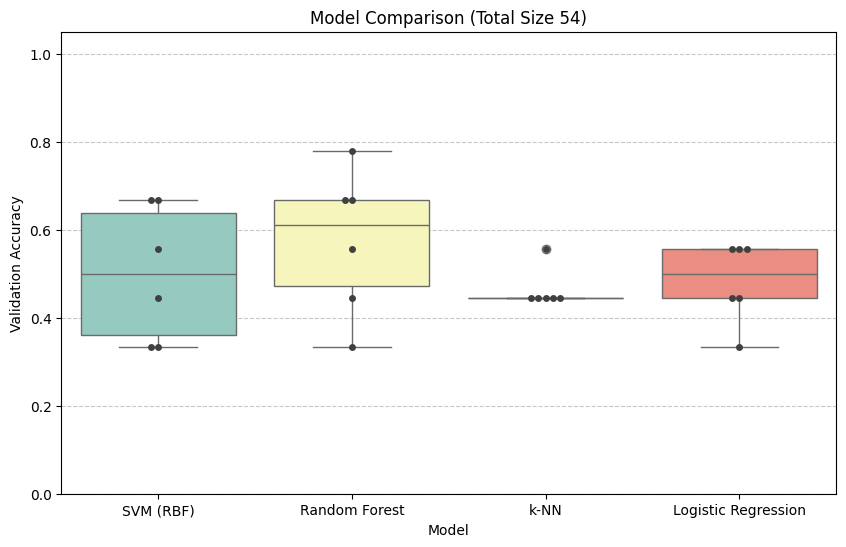

In [18]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# --- 比較したいモデルたち ---
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

def main():
    # ==========================================
    # 1. 設定
    # ==========================================
    FEATURE_CSV_PATH = "/home/data/0107_tomine/feature_huall.csv"
    DATASET_ROOT = "/home/data/0107_generated_datasets_aug"
    OUTPUT_DIR = "/home/src/deeplerning_model/CNNvsmine/multi_model_comparison"
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    FEATURE_COLS = ['size_count', 'R', 'h0', 'h2', 'h3', 'h7']
    TARGET_SIZE = 54  # 比較したいデータサイズ
    
    CLASS_NAMES = ['A', 'B', 'C']
    LABEL_MAP = {name: i for i, name in enumerate(CLASS_NAMES)}

    # -------------------------------------------------------
    # 2. データ準備 (共通処理)
    # -------------------------------------------------------
    if not os.path.exists(FEATURE_CSV_PATH):
        print("エラー: CSVなし")
        return
    
    df_raw = pd.read_csv(FEATURE_CSV_PATH)
    for col in FEATURE_COLS:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
    df_raw = df_raw.dropna(subset=FEATURE_COLS)

    def get_clean_key(filename):
        name = str(filename)
        name = os.path.splitext(name)[0]
        for suffix in ['_mask', '_crop', '_combined']:
            name = name.replace(suffix, '')
        return name

    df_raw['match_key'] = df_raw['filename'].apply(get_clean_key)
    df_features = df_raw.drop_duplicates(subset=['match_key']).set_index('match_key')

    # -------------------------------------------------------
    # 3. モデルと比較設定の定義
    # -------------------------------------------------------
    # 各モデルと、探索するパラメータグリッド
    models_config = {
        'SVM (RBF)': {
            'model': SVC(class_weight='balanced', random_state=42),
            'params': {
                'clf__C': [0.1, 1, 10, 100],
                'clf__gamma': ['scale', 'auto'],
                'clf__kernel': ['rbf']
            }
        },
        'Random Forest': {
            'model': RandomForestClassifier(class_weight='balanced', random_state=42),
            'params': {
                'clf__n_estimators': [50, 100, 200], # 木の本数
                'clf__max_depth': [3, 5, 10, None],  # 木の深さ(浅いほうが過学習しにくい)
                'clf__min_samples_split': [2, 5]
            }
        },
        'k-NN': {
            'model': KNeighborsClassifier(),
            'params': {
                'clf__n_neighbors': [3, 5, 7, 9],    # 近所を見る数
                'clf__weights': ['uniform', 'distance']
            }
        },
        'Logistic Regression': {
            'model': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
            'params': {
                'clf__C': [0.1, 1, 10, 100],
                'clf__solver': ['lbfgs', 'liblinear']
            }
        }
    }

    # -------------------------------------------------------
    # 4. 学習・評価ループ
    # -------------------------------------------------------
    print(f"★ Comparing models on Data Size: {TARGET_SIZE}")
    size_root = os.path.join(DATASET_ROOT, f"Total_{TARGET_SIZE}")
    
    # 結果格納用
    comparison_results = []

    for fold in range(1, 7):
        fold_name = f"Fold_{fold}"
        fold_dir = os.path.join(size_root, fold_name)
        if not os.path.exists(fold_dir): continue
        
        print(f"\n--- {fold_name} ---")

        # データロード
        def load_data(phase):
            phase_dir = os.path.join(fold_dir, phase)
            X, y = [], []
            for cls in CLASS_NAMES:
                d = os.path.join(phase_dir, cls)
                if not os.path.exists(d): continue
                for f in os.listdir(d):
                    if not f.endswith('.png'): continue
                    k = get_clean_key(os.path.splitext(f)[0].replace('_flip','').replace('_rot30','').replace('_rot_30',''))
                    if k in df_features.index:
                        X.append(df_features.loc[k, FEATURE_COLS].values.astype(float))
                        y.append(LABEL_MAP[cls])
            return np.array(X), np.array(y)

        X_train, y_train = load_data('train')
        X_val, y_val = load_data('val')

        if len(X_train) == 0: continue

        # --- モデルごとに学習 ---
        for model_name, config in models_config.items():
            pipeline = Pipeline([
                ('scaler', StandardScaler()), # 全モデルで標準化しておくのが無難
                ('clf', config['model'])
            ])
            
            # グリッドサーチ
            grid = GridSearchCV(pipeline, config['params'], cv=3, scoring='accuracy', n_jobs=-1)
            grid.fit(X_train, y_train)
            
            # 評価
            best_model = grid.best_estimator_
            val_acc = accuracy_score(y_val, best_model.predict(X_val))
            
            # 結果保存
            comparison_results.append({
                'Fold': fold,
                'Model': model_name,
                'Val_Accuracy': val_acc,
                'Best_Params': str(grid.best_params_)
            })

    # -------------------------------------------------------
    # 5. 集計とグラフ化
    # -------------------------------------------------------
    if comparison_results:
        df_res = pd.DataFrame(comparison_results)
        
        # モデルごとの平均スコアを算出
        avg_scores = df_res.groupby('Model')['Val_Accuracy'].mean().sort_values(ascending=False)
        print("\n=== Model Ranking (Average Accuracy) ===")
        print(avg_scores)
        
        # CSV保存
        df_res.to_csv(os.path.join(OUTPUT_DIR, "model_comparison_details.csv"), index=False)
        
        # 箱ひげ図でばらつきを含めて可視化
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='Model', y='Val_Accuracy', data=df_res, palette="Set3")
        sns.swarmplot(x='Model', y='Val_Accuracy', data=df_res, color=".25") # 点もプロット
        
        plt.title(f'Model Comparison (Total Size {TARGET_SIZE})')
        plt.ylabel('Validation Accuracy')
        plt.ylim(0, 1.05)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        save_path = os.path.join(OUTPUT_DIR, "model_comparison_boxplot.png")
        plt.savefig(save_path)
        print(f"\nSaved Graph: {save_path}")
        
    else:
        print("結果が得られませんでした。")

if __name__ == "__main__":
    main()

★ Starting Random Forest Analysis for Total_54

--- Fold_1 ---
  Best Params: {'clf__max_depth': 5, 'clf__max_features': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 50}
  Val Accuracy: 0.6667

--- Fold_2 ---
  Best Params: {'clf__max_depth': 7, 'clf__max_features': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 50}
  Val Accuracy: 0.4444

--- Fold_3 ---
  Best Params: {'clf__max_depth': 7, 'clf__max_features': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 50}
  Val Accuracy: 0.4444

--- Fold_4 ---
  Best Params: {'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 2, 'clf__n_estimators': 50}
  Val Accuracy: 0.4444

--- Fold_5 ---
  Best Params: {'clf__max_depth': 5, 'clf__max_features': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
  Val Accuracy: 0.6667

--- Fold_6 ---
  Best Params: {'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
  Val Accuracy: 0.3333

=== 

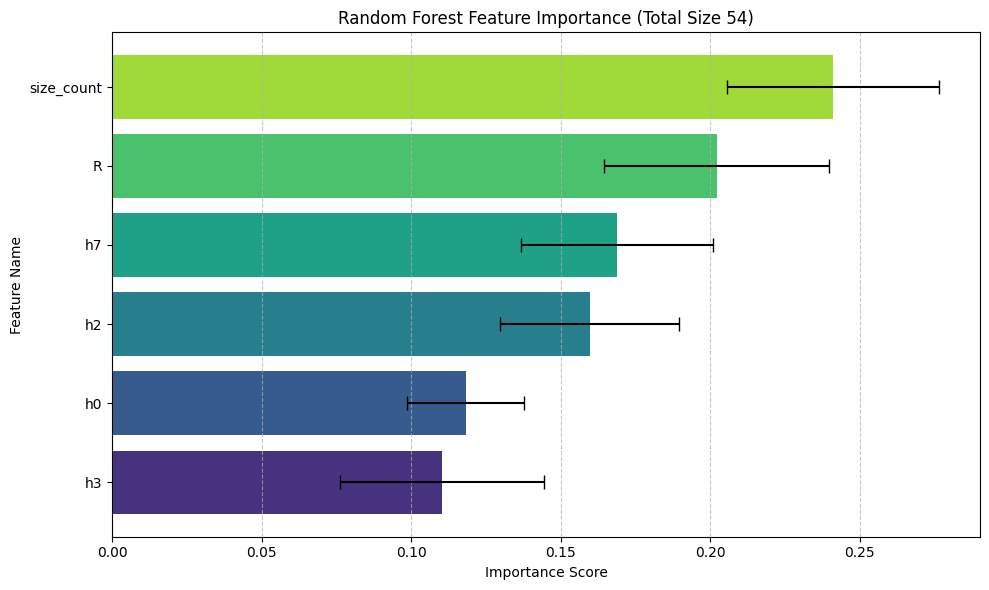

In [20]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

def main():
    # ==========================================
    # 1. 設定
    # ==========================================
    FEATURE_CSV_PATH = "/home/data/0107_tomine/feature_huall.csv"
    DATASET_ROOT = "/home/data/0107_generated_datasets_aug"
    OUTPUT_DIR = "/home/src/deeplerning_model/CNNvsmine/rf_analysis_54"
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    FEATURE_COLS = ['size_count', 'R', 'h0', 'h2', 'h3', 'h7']
    TARGET_SIZE = 54 
    
    CLASS_NAMES = ['A', 'B', 'C']
    LABEL_MAP = {name: i for i, name in enumerate(CLASS_NAMES)}

    # -------------------------------------------------------
    # 2. データ準備
    # -------------------------------------------------------
    if not os.path.exists(FEATURE_CSV_PATH):
        print("エラー: CSVなし")
        return

    df_raw = pd.read_csv(FEATURE_CSV_PATH)
    for col in FEATURE_COLS:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
    df_raw = df_raw.dropna(subset=FEATURE_COLS)

    def get_clean_key(filename):
        name = str(filename)
        name = os.path.splitext(name)[0]
        for suffix in ['_mask', '_crop', '_combined']:
            name = name.replace(suffix, '')
        return name

    df_raw['match_key'] = df_raw['filename'].apply(get_clean_key)
    df_features = df_raw.drop_duplicates(subset=['match_key']).set_index('match_key')

    # -------------------------------------------------------
    # 3. Random Forest 最適化 & 重要度分析
    # -------------------------------------------------------
    print(f"★ Starting Random Forest Analysis for Total_{TARGET_SIZE}")
    size_root = os.path.join(DATASET_ROOT, f"Total_{TARGET_SIZE}")
    
    # 全Foldでの重要度を平均するためにリスト化
    feature_importances_list = []
    best_accuracies = []

    for fold in range(1, 7):
        fold_name = f"Fold_{fold}"
        fold_dir = os.path.join(size_root, fold_name)
        if not os.path.exists(fold_dir): continue
        
        print(f"\n--- {fold_name} ---")

        # データ読み込み
        def load_data(phase):
            phase_dir = os.path.join(fold_dir, phase)
            X, y = [], []
            for cls in CLASS_NAMES:
                d = os.path.join(phase_dir, cls)
                if not os.path.exists(d): continue
                for f in os.listdir(d):
                    if not f.endswith('.png'): continue
                    k = get_clean_key(os.path.splitext(f)[0].replace('_flip','').replace('_rot30','').replace('_rot_30',''))
                    if k in df_features.index:
                        X.append(df_features.loc[k, FEATURE_COLS].values.astype(float))
                        y.append(LABEL_MAP[cls])
            return np.array(X), np.array(y)

        X_train, y_train = load_data('train')
        X_val, y_val = load_data('val')

        if len(X_train) == 0: continue

        # --- パラメータ探索範囲 ---
        # 決定木は「深さ」と「木の数」が重要です
        param_grid = {
            'clf__n_estimators': [50, 100, 200, 300],      # 木の数（多いほうが安定する）
            'clf__max_depth': [3, 5, 7, 10, None],         # 木の深さ（浅いと単純、深いと複雑）
            'clf__min_samples_split': [2, 5, 10],          # 分割するのに必要な最小データ数
            'clf__max_features': ['sqrt', 'log2', None]    # 特徴量の選び方
        }

        pipeline = Pipeline([
            # RFはスケーリング必須ではないですが、他と条件を揃えるため入れても害はないです
            ('scaler', StandardScaler()), 
            ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
        ])

        grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
        grid.fit(X_train, y_train)

        # ベストモデルの評価
        best_model = grid.best_estimator_
        val_acc = accuracy_score(y_val, best_model.predict(X_val))
        best_accuracies.append(val_acc)
        
        print(f"  Best Params: {grid.best_params_}")
        print(f"  Val Accuracy: {val_acc:.4f}")

        # --- 特徴量重要度の抽出 ---
        # Pipelineを使っている場合、中のclfステップから取り出す必要があります
        rf_model = best_model.named_steps['clf']
        importances = rf_model.feature_importances_
        feature_importances_list.append(importances)

# -------------------------------------------------------
    # 4. 結果の可視化 (重要度)
    # -------------------------------------------------------
    if feature_importances_list:
        # 平均重要度を計算
        avg_importances = np.mean(feature_importances_list, axis=0)
        std_importances = np.std(feature_importances_list, axis=0)
        
        # DataFrame化
        df_imp = pd.DataFrame({
            'Feature': FEATURE_COLS,
            'Importance': avg_importances,
            'Std': std_importances
        })
        # グラフで見やすいようにソート（重要度が高い順）
        df_imp = df_imp.sort_values(by='Importance', ascending=True) # barhは下から描画されるため昇順にする
        
        print("\n=== Feature Importances (Average) ===")
        # 表示用には降順で出力
        print(df_imp.sort_values(by='Importance', ascending=False))
        
        # グラフ作成 (Seaborn -> Matplotlibに変更)
        plt.figure(figsize=(10, 6))
        
        # 横棒グラフを描画 (barh)
        # xerr引数に標準偏差を渡すことでエラーバーを描画できます
        plt.barh(
            y=df_imp['Feature'], 
            width=df_imp['Importance'], 
            xerr=df_imp['Std'], 
            color=sns.color_palette('viridis', len(df_imp)), # 色はSeabornのパレットを使用
            capsize=5 # エラーバーの先端の横棒のサイズ
        )
        
        plt.title(f'Random Forest Feature Importance (Total Size {TARGET_SIZE})')
        plt.xlabel('Importance Score')
        plt.ylabel('Feature Name')
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        
        save_path = os.path.join(OUTPUT_DIR, "rf_feature_importance.png")
        plt.savefig(save_path)
        print(f"\nSaved Importance Graph: {save_path}")
        
        # 平均精度も表示
        print(f"Average RF Accuracy over 6 folds: {np.mean(best_accuracies):.4f}")
    else:
        print("結果が得られませんでした。")

if __name__ == "__main__":
    main()

★ Comparing Tree-based models on Data Size: 54

--- Fold_1 ---

--- Fold_2 ---

--- Fold_3 ---

--- Fold_4 ---

--- Fold_5 ---

--- Fold_6 ---

=== Model Ranking (Average Accuracy) ===
Model
Random Forest        0.574074
Extra Trees          0.518519
Gradient Boosting    0.518519
Decision Tree        0.481481
Name: Val_Accuracy, dtype: float64

Saved Graph: /home/src/deeplerning_model/CNNvsmine/tree_models_comparison/tree_models_comparison_boxplot.png


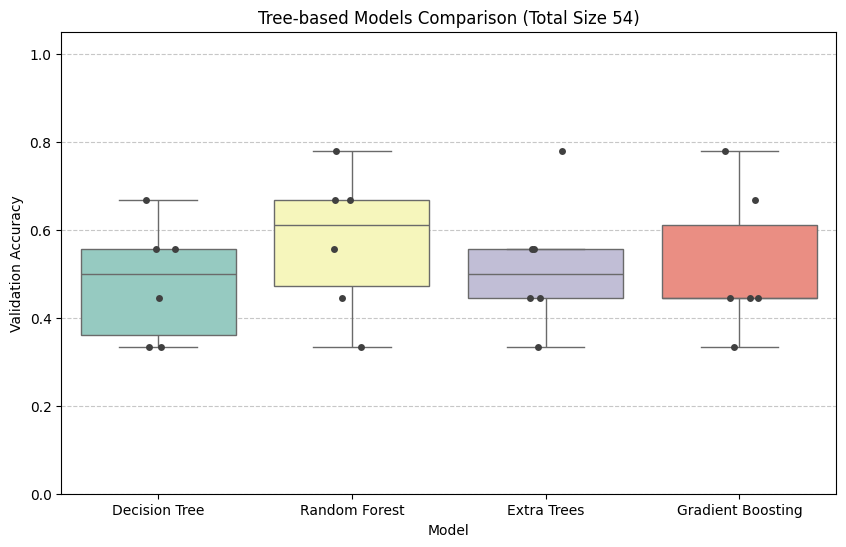

In [21]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearnの木系モデル
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

def main():
    # ==========================================
    # 1. 設定
    # ==========================================
    FEATURE_CSV_PATH = "/home/data/0107_tomine/feature_huall.csv"
    DATASET_ROOT = "/home/data/0107_generated_datasets_aug"
    OUTPUT_DIR = "/home/src/deeplerning_model/CNNvsmine/tree_models_comparison"
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    FEATURE_COLS = ['size_count', 'R', 'h0', 'h2', 'h3', 'h7']
    TARGET_SIZE = 54  # ターゲットとするデータサイズ
    
    CLASS_NAMES = ['A', 'B', 'C']
    LABEL_MAP = {name: i for i, name in enumerate(CLASS_NAMES)}

    # -------------------------------------------------------
    # 2. データ準備
    # -------------------------------------------------------
    if not os.path.exists(FEATURE_CSV_PATH):
        print("エラー: CSVなし")
        return

    df_raw = pd.read_csv(FEATURE_CSV_PATH)
    for col in FEATURE_COLS:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
    df_raw = df_raw.dropna(subset=FEATURE_COLS)

    def get_clean_key(filename):
        name = str(filename)
        name = os.path.splitext(name)[0]
        for suffix in ['_mask', '_crop', '_combined']:
            name = name.replace(suffix, '')
        return name

    df_raw['match_key'] = df_raw['filename'].apply(get_clean_key)
    df_features = df_raw.drop_duplicates(subset=['match_key']).set_index('match_key')

    # -------------------------------------------------------
    # 3. モデルと比較設定
    # -------------------------------------------------------
    # 木系モデルのラインナップ
    models_config = {
        # 1. 決定木 (単体)
        'Decision Tree': {
            'model': DecisionTreeClassifier(class_weight='balanced', random_state=42),
            'params': {
                'clf__max_depth': [3, 5, 7, 10, None],
                'clf__min_samples_split': [2, 5, 10],
                'clf__criterion': ['gini', 'entropy']
            }
        },
        # 2. ランダムフォレスト (バギング)
        'Random Forest': {
            'model': RandomForestClassifier(class_weight='balanced', random_state=42),
            'params': {
                'clf__n_estimators': [50, 100, 200],
                'clf__max_depth': [3, 5, 10, None],
                'clf__max_features': ['sqrt', 'log2']
            }
        },
        # 3. Extra Trees (さらにランダム性を高めた森)
        # ★小規模データではRFより強いことが多い
        'Extra Trees': {
            'model': ExtraTreesClassifier(class_weight='balanced', random_state=42),
            'params': {
                'clf__n_estimators': [50, 100, 200],
                'clf__max_depth': [3, 5, 10, None],
                'clf__min_samples_split': [2, 5]
            }
        },
        # 4. 勾配ブースティング (ブースティング)
        'Gradient Boosting': {
            'model': GradientBoostingClassifier(random_state=42),
            'params': {
                'clf__n_estimators': [50, 100],
                'clf__learning_rate': [0.01, 0.1, 0.2],
                'clf__max_depth': [3, 5], # 深すぎると過学習するので浅めに
                'clf__subsample': [0.8, 1.0]
            }
        }
    }

    # -------------------------------------------------------
    # 4. 学習ループ
    # -------------------------------------------------------
    print(f"★ Comparing Tree-based models on Data Size: {TARGET_SIZE}")
    size_root = os.path.join(DATASET_ROOT, f"Total_{TARGET_SIZE}")
    
    comparison_results = []

    for fold in range(1, 7):
        fold_name = f"Fold_{fold}"
        fold_dir = os.path.join(size_root, fold_name)
        if not os.path.exists(fold_dir): continue
        
        print(f"\n--- {fold_name} ---")

        # データロード関数
        def load_data(phase):
            phase_dir = os.path.join(fold_dir, phase)
            X, y = [], []
            for cls in CLASS_NAMES:
                d = os.path.join(phase_dir, cls)
                if not os.path.exists(d): continue
                for f in os.listdir(d):
                    if not f.endswith('.png'): continue
                    k = get_clean_key(os.path.splitext(f)[0].replace('_flip','').replace('_rot30','').replace('_rot_30',''))
                    if k in df_features.index:
                        X.append(df_features.loc[k, FEATURE_COLS].values.astype(float))
                        y.append(LABEL_MAP[cls])
            return np.array(X), np.array(y)

        X_train, y_train = load_data('train')
        X_val, y_val = load_data('val')

        if len(X_train) == 0: continue

        # 各モデルで学習
        for model_name, config in models_config.items():
            pipeline = Pipeline([
                ('scaler', StandardScaler()), # 木系は必須ではないが入れたほうが安定する
                ('clf', config['model'])
            ])
            
            grid = GridSearchCV(pipeline, config['params'], cv=3, scoring='accuracy', n_jobs=-1)
            grid.fit(X_train, y_train)
            
            best_model = grid.best_estimator_
            val_acc = accuracy_score(y_val, best_model.predict(X_val))
            
            comparison_results.append({
                'Fold': fold,
                'Model': model_name,
                'Val_Accuracy': val_acc,
                'Best_Params': str(grid.best_params_)
            })

    # -------------------------------------------------------
    # 5. 集計とグラフ化
    # -------------------------------------------------------
    if comparison_results:
        df_res = pd.DataFrame(comparison_results)
        
        # ランキング表示
        avg_scores = df_res.groupby('Model')['Val_Accuracy'].mean().sort_values(ascending=False)
        print("\n=== Model Ranking (Average Accuracy) ===")
        print(avg_scores)
        
        # CSV保存
        df_res.to_csv(os.path.join(OUTPUT_DIR, "tree_models_comparison.csv"), index=False)
        
        # 箱ひげ図
        plt.figure(figsize=(10, 6))
        # 箱ひげ図
        sns.boxplot(x='Model', y='Val_Accuracy', data=df_res, palette="Set3", showfliers=False)
        # 個別データのプロット (swarmplotの代わりにstripplotを使用するとエラーが起きにくい)
        sns.stripplot(x='Model', y='Val_Accuracy', data=df_res, color=".25", jitter=True)
        
        plt.title(f'Tree-based Models Comparison (Total Size {TARGET_SIZE})')
        plt.ylabel('Validation Accuracy')
        plt.ylim(0, 1.05)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        save_path = os.path.join(OUTPUT_DIR, "tree_models_comparison_boxplot.png")
        plt.savefig(save_path)
        print(f"\nSaved Graph: {save_path}")
        
    else:
        print("結果が得られませんでした。")

if __name__ == "__main__":
    main()

In [23]:
import pandas as pd
import re
import io

def sort_csv_by_img_number():
    # ---------------------------------------------------------
    # 1. 設定: ファイルパス
    # ---------------------------------------------------------
    INPUT_CSV_PATH = '/home/data/0107_tomine/feature_huall.csv'      # 読み込むCSVファイル名
    OUTPUT_CSV_PATH = '/home/data/0107_tomine/feature_huall_syo.csv' # 保存するCSVファイル名
    
    # 実際のファイルを使う場合は、以下の行のコメントアウト(#)を外し、上の csv_data 読み込みを削除してください
    if os.path.exists(INPUT_CSV_PATH):
        df = pd.read_csv(INPUT_CSV_PATH)
    else:
        print("ファイルが見つからないためテストデータを使用します")
    # df = pd.read_csv(io.StringIO(csv_data))

    # ---------------------------------------------------------
    # 2. 数値抽出ロジック
    # ---------------------------------------------------------
    def extract_number(filename):
        # 正規表現で "IMG_" の後ろにある数字の塊 (\d+) を探す
        match = re.search(r'IMG_(\d+)', str(filename))
        if match:
            return int(match.group(1)) # 見つかったら整数に変換して返す
        return 0 # 見つからなければ0 (最後尾などに回すため)

    # ---------------------------------------------------------
    # 3. ソート処理
    # ---------------------------------------------------------
    # 一時的にソート用の列 'sort_key' を作成
    df['sort_key'] = df['filename'].apply(extract_number)
    
    # sort_key に基づいて昇順ソート
    df_sorted = df.sort_values(by='sort_key', ascending=True)
    
    # 一時的な列を削除
    df_sorted = df_sorted.drop(columns=['sort_key'])

    # ---------------------------------------------------------
    # 4. 結果確認と保存
    # ---------------------------------------------------------
    print("--- ソート結果 (filenameのみ表示) ---")
    print(df_sorted['filename'])
    
    # CSV保存
    df_sorted.to_csv(OUTPUT_CSV_PATH, index=False)
    print(f"\n保存しました: {OUTPUT_CSV_PATH}")

if __name__ == '__main__':
    sort_csv_by_img_number()

--- ソート結果 (filenameのみ表示) ---
171             IMG_6420_mask.png
218      IMG_6420_mask_rot_30.png
27        IMG_6420_mask_rot30.png
305        IMG_6420_mask_flip.png
248        IMG_6421_mask_flip.png
                  ...            
65       IMG_66736_mask_rot30.png
965      IMG_66739_mask_rot30.png
1013           IMG_66739_mask.png
145     IMG_66739_mask_rot_30.png
809       IMG_66739_mask_flip.png
Name: filename, Length: 2684, dtype: object

保存しました: /home/data/0107_tomine/feature_huall_syo.csv
